# 1. Import Libraries

In [21]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px

# 2. Tải bộ dữ liệu "mpg" từ seaborn

In [22]:
df=sns.load_dataset("mpg")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


# 3. Xử lý dữ liệu


In [23]:
cats = list(df.select_dtypes(include=['object']).columns)
nums = list(df.select_dtypes(exclude=['object']).columns)
print(f'categorical variables:  {cats}')
print(f'numerical variables:  {nums}')

categorical variables:  ['origin', 'name']
numerical variables:  ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']


In [24]:
# Xem thông tin chung về dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [25]:
# Thay các biến không có nghĩa của horsepower bằng các biến có giá trị trung bình horsepower
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean()) #Em định bỏ các biến null nhưng thay bằng biến trung bình để dữ liệu ít sai số nhất ạ.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [26]:
origin_counts = df['origin'].value_counts()

print(origin_counts)

origin
usa       249
japan      79
europe     70
Name: count, dtype: int64


In [27]:
# Đếm số lượng xe theo số xi-lanh
cylinder_counts = df['cylinders'].value_counts()

print(cylinder_counts)

cylinders
4    204
8    103
6     84
3      4
5      3
Name: count, dtype: int64


In [28]:
# Tổng hợp nhiều giá trị thống kê
stats_by_cylinders = df.groupby('cylinders').agg(
    avg_mpg=('mpg', 'mean'),
    max_weight=('weight', 'max'),
    min_weight=('weight', 'min'),
    count=('name', 'count')
).reset_index()

print(stats_by_cylinders)


   cylinders    avg_mpg  max_weight  min_weight  count
0          3  20.550000        2720        2124      4
1          4  29.286765        3270        1613    204
2          5  27.366667        3530        2830      3
3          6  19.985714        3907        2472     84
4          8  14.963107        5140        3086    103


In [29]:
cars_per_year = df['model_year'].value_counts().sort_index()

print(cars_per_year)


model_year
70    29
71    28
72    28
73    40
74    27
75    30
76    34
77    28
78    36
79    29
80    29
81    29
82    31
Name: count, dtype: int64


# 4. Trực quan hoá dữ liệu

##Qua các năm sản xuất, số lượng xe xuất xứ từ nước nào là nhiều nhất?

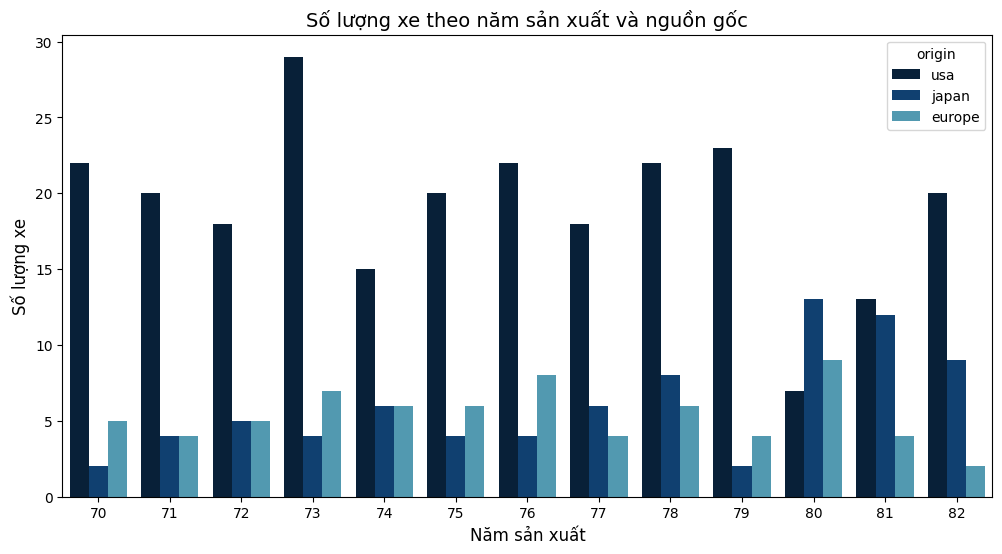

In [42]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='model_year', hue='origin', palette='ocean')
plt.title('Số lượng xe theo năm sản xuất và nguồn gốc', fontsize=14)
plt.xlabel('Năm sản xuất', fontsize=12)
plt.ylabel('Số lượng xe', fontsize=12)
labels={'model_year': 'Năm sản xuất', 'count': 'Số lượng xe', 'manufacturer': 'Hãng xe'},
plt.show()


Nhận xét:
- Trong các năm đầu (1970-1975), xe Mỹ có số lượng vượt trội so với xe Nhật và Châu Âu.
- Từ năm 1980, số lượng xe Nhật Bản tăng so với các năm trước, số lượng xe Mỹ giảm nhẹ.
- Xe Châu Âu không có sự thay đổi đáng kể qua các năm, giữ một lượng ổn định nhưng thấp hơn hẳn so với hai khu vực còn lại.
1. Số lượng xe qua các năm:

- Năm 1973 là năm có số lượng xe xuất xứ từ Mỹ lớn nhất so với các xe sản xuất ở những năm còn lại.
- Năm 1980-1982: Đây là giai đoạn xe Nhật Bản vươn lên mạnh mẽ, số lượng tăng đáng kể và gần đuổi kịp xe Mỹ.
2. Kết luận:

Biểu đồ cho thấy sự thống trị của xe Mỹ trong thập niên 70 và sự trỗi dậy mạnh mẽ của xe Nhật Bản trong thập niên 80. Xe Châu Âu giữ vai trò trung lập, với số lượng ổn định qua các năm.

## Xu hướng hiệu suất nhiên liệu theo năm sản xuất diễn ra như thế nào?


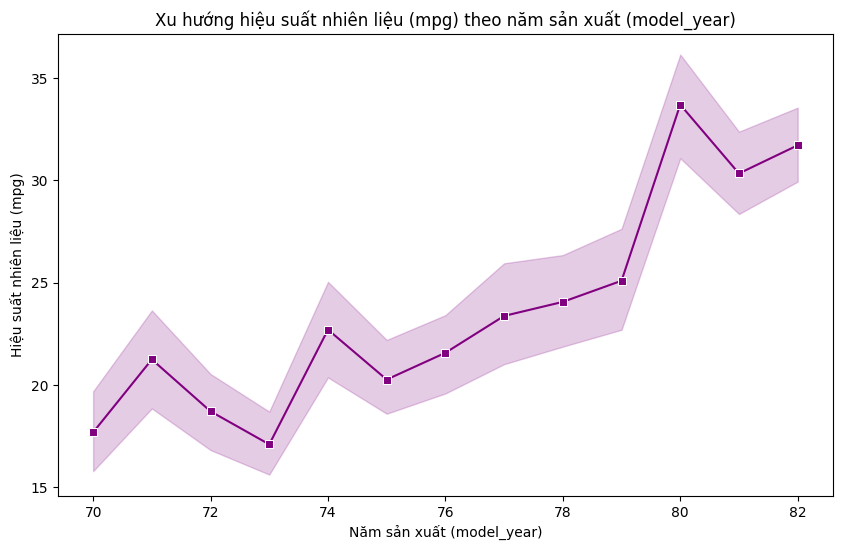

In [31]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="model_year", y="mpg", marker="s", color="purple")
plt.title("Xu hướng hiệu suất nhiên liệu (mpg) theo năm sản xuất (model_year)")
plt.xlabel("Năm sản xuất (model_year)")
plt.ylabel("Hiệu suất nhiên liệu (mpg)")
plt.show()

Nhận xét:
1. Hiệu suất nhiên liệu (mpg) tăng dần theo thời gian, đặc biệt rõ rệt từ năm 1975 trở đi.
Điều này phản ánh sự phát triển của công nghệ động cơ, sự quan tâm đến tiết kiệm nhiên liệu và các quy định môi trường nghiêm ngặt hơn trong ngành công nghiệp ô tô.

2. Các xe xuất xứ năm 1973 có hiệu suất nhiên liệu thấp nhất có thể là do Cuộc khủng hoảng dầu mỏ năm 1973.

- Đến năm 1974 thì hiệu suất tăng dần, cho thấy ngành công nghiệp ô tô đang trên đà phát triển trở lại.

3. Khoảng dao động (dải màu tím nhạt):
- Dải dao động rộng hơn ở các năm đầu (1970–1974) cho thấy sự đa dạng về mức tiêu thụ nhiên liệu trong các mẫu xe thời kỳ này, từ xe tiết kiệm nhiên liệu đến xe tiêu hao nhiều nhiên liệu.

- Sau năm 1980, dải dao động thu hẹp lại, cho thấy các mẫu xe mới dần tập trung hơn vào hiệu suất nhiên liệu cao.
4. Điểm nổi bật:

- Có sự giảm nhẹ hiệu suất nhiên liệu ở khoảng năm 1974, có thể do các yếu tố kinh tế hoặc công nghệ trong thời kỳ này.
- Tăng mạnh từ năm 1978 đến năm 1980, đây có thể là kết quả của cuộc khủng hoảng dầu mỏ, thúc đẩy việc sản xuất xe tiết kiệm nhiên liệu hơn.

5. Kết luận:
Các nhà sản xuất ô tô đã thích nghi với yêu cầu thị trường và chính sách về môi trường, hướng tới các dòng xe nhẹ hơn, động cơ tối ưu hơn.

##Mối liên hệ giữa MPG và Weight qua từng năm sản xuất của các nước diễn ra như thế nào?

In [32]:
fig = px.scatter(df, x="weight", y="mpg", size="model_year", color="origin",
                 animation_frame="model_year", hover_name="name", size_max=40,
                 color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_layout(title="Animated Bubble Plot of MPG by Weight with Model_Year",
    title_font=dict(family="small-caps", size=26, color="darkgreen"))
fig.show()

Nhận xét:
- Dù xe sản xuất năm nào, thì xe xuất xứ ở USA luôn chiếm số lượng nhiều hơn các nước còn lại
- Các xe xuất xứ trước năm 1975 từ Japan và Europe đã có giá trị hiệu suất nhiên liệu cao hơn so với xe xuất xứ từ USA, xe có hiệu xuất nhiên liệu càng cao, càng tiết kiệm nhiên liệu.


1. Mối quan hệ giữa trọng lượng xe (weight) và hiệu suất nhiên liệu (mpg):
- Xe có trọng lượng lớn hơn thường có hiệu suất nhiên liệu thấp hơn (MPG thấp).
Điều này nhất quán với xu hướng thông thường: xe nặng tiêu tốn nhiều nhiên liệu hơn.

2. Tác động của model_year:
- Khi khung thời gian di chuyển qua từng năm sản xuất, có xu hướng xe trở nên nhẹ hơn và có MPG cao hơn, thể hiện sự phát triển trong công nghệ và ưu tiên tiết kiệm nhiên liệu.
Màu sắc đại diện cho quốc gia xuất xứ (origin):

3. Xe từ các quốc gia khác nhau (ví dụ: Mỹ, Nhật Bản, Châu Âu) có đặc điểm phân bố khác biệt:
- Xe Mỹ thường nặng hơn và có MPG thấp hơn, tuy vậy nhưng xe xuất xứ từ Mỹ được ưa chuộng hơn các xe xuất xứ từ Japan và Europe.
- Xe Nhật Bản và Châu Âu thường nhẹ hơn và tiết kiệm nhiên liệu hơn.

4. Kích thước bong bóng đại diện cho năm sản xuất (size="model_year"):
- Các bong bóng lớn hơn (tương ứng với các năm sản xuất gần đây hơn) cho thấy sự chuyển dịch sang xe nhẹ và tiết kiệm nhiên liệu.

5. hover_name="name":
Việc hiển thị tên xe giúp người dùng dễ dàng tìm hiểu từng mẫu xe cụ thể, rất hữu ích cho phân tích chi tiết.

6. Kết luận:
Xe ngày càng tối ưu hóa trọng lượng và tiết kiệm nhiên liệu hơn, với sự khác biệt rõ ràng giữa các quốc gia sản xuất.



## Số xi-lanh có ảnh hưởng đến hiệu suất nhiên liệu không?

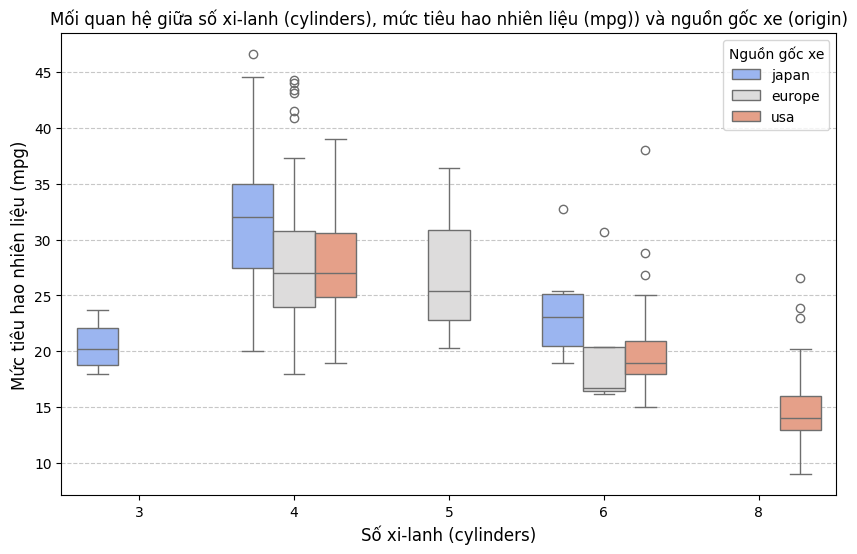

In [60]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='cylinders', y='mpg', hue='origin', palette='coolwarm')
plt.title('Mối quan hệ giữa số xi-lanh (cylinders), mức tiêu hao nhiên liệu (mpg)) và nguồn gốc xe (origin)')
plt.xlabel('Số xi-lanh (cylinders)', fontsize=12)
plt.ylabel('Mức tiêu hao nhiên liệu (mpg)', fontsize=12)
plt.legend(title='Nguồn gốc xe', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Nhận xét:
1. Phân phối mức tiêu hao nhiên liệu (mpg) theo số xi-lanh:

- Xe có 4 xi-lanh có mức tiêu hao nhiên liệu cao nhất, với mpg dao động từ khoảng 20 đến 35, và một số giá trị vượt ngưỡng 40.
- Xe có 6 xi-lanh có mức tiêu hao nhiên liệu trung bình, dao động từ khoảng 15 đến 25 mpg.
- Xe có 8 xi-lanh có mức tiêu hao nhiên liệu thấp nhất, thường nằm trong khoảng 10–20 mpg, cho thấy đây là các dòng xe tiêu tốn nhiên liệu nhất.

2. Khi số xi-lanh tăng lên, mức tiêu hao nhiên liệu (mpg) giảm dần. Điều này phù hợp với lý thuyết, vì động cơ có nhiều xi-lanh hơn thường mạnh hơn nhưng cũng tiêu tốn nhiên liệu nhiều hơn.

##Mã lực (horsepower) có mối quan hệ gì với hiệu suất nhiên liệu (mpg) và số lượng xi-lanh (cylinders)?


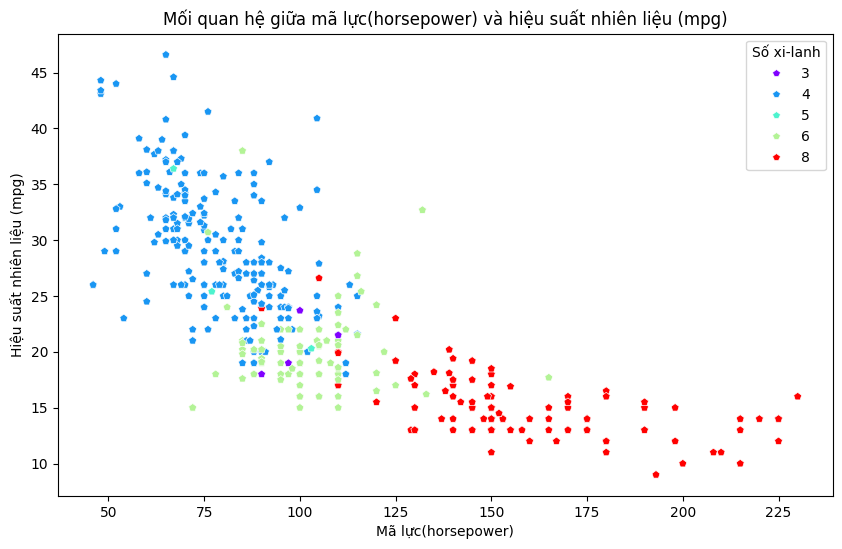

In [55]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="horsepower", y="mpg", hue="cylinders", palette="rainbow", marker='p')
plt.title("Mối quan hệ giữa mã lực(horsepower) và hiệu suất nhiên liệu (mpg)")
plt.xlabel("Mã lực(horsepower)")
plt.ylabel("Hiệu suất nhiên liệu (mpg)")
plt.legend(title="Số xi-lanh")
plt.show()

Nhận xét:
1. Mã lực (horsepower) tỉ lệ nghịch với hiệu suất nhiên liệu
(mpg), mã lực càng tăng thì hiệu suất nhiên liệu càng giảm.
2. Cho thấy khi xe có động cơ lớn (hay mã lực mạnh) thì sẽ tiêu hao nhiều nhiên liệu.
3. Ảnh hưởng của xi-lanh lên mã lực:
- Xe có 4 xi-lanh (màu xanh dương): Chiếm đa số trong các xe có hiệu suất nhiên liệu cao (MPG cao từ 30 đến 45). Những xe này thường có mã lực thấp hoặc trung bình (khoảng 50–100).
- Xe có 6 xi-lanh (màu xanh lá): Nằm ở khoảng giữa, với mã lực từ 100–150 và MPG giảm xuống mức trung bình (15–30 MPG).
- Xe có 8 xi-lanh (màu đỏ): Tập trung ở vùng mã lực cao (125–225) và hiệu suất nhiên liệu thấp (10–20 MPG). Đây là các xe mạnh mẽ nhưng tiêu thụ nhiên liệu nhiều.
- Xe có 3 xi-lanh (màu tím) và 5 xi-lanh (màu xanh lam): Ít xuất hiện hơn, nhưng hiệu suất nhiên liệu cao hơn, phù hợp với các xe nhỏ hoặc tiết kiệm nhiên liệu.
4. Kết luận:
- Động cơ 4 xi-lanh là tối ưu về mặt cân bằng giữa mã lực và hiệu suất nhiên liệu.
- Các xe có mã lực lớn hơn và nhiều xi-lanh phù hợp với nhu cầu vận hành mạnh mẽ nhưng không tối ưu về tiết kiệm nhiên liệu.

## Động cơ của xe xuất xứ 3 nước khác nhau như thế nào?


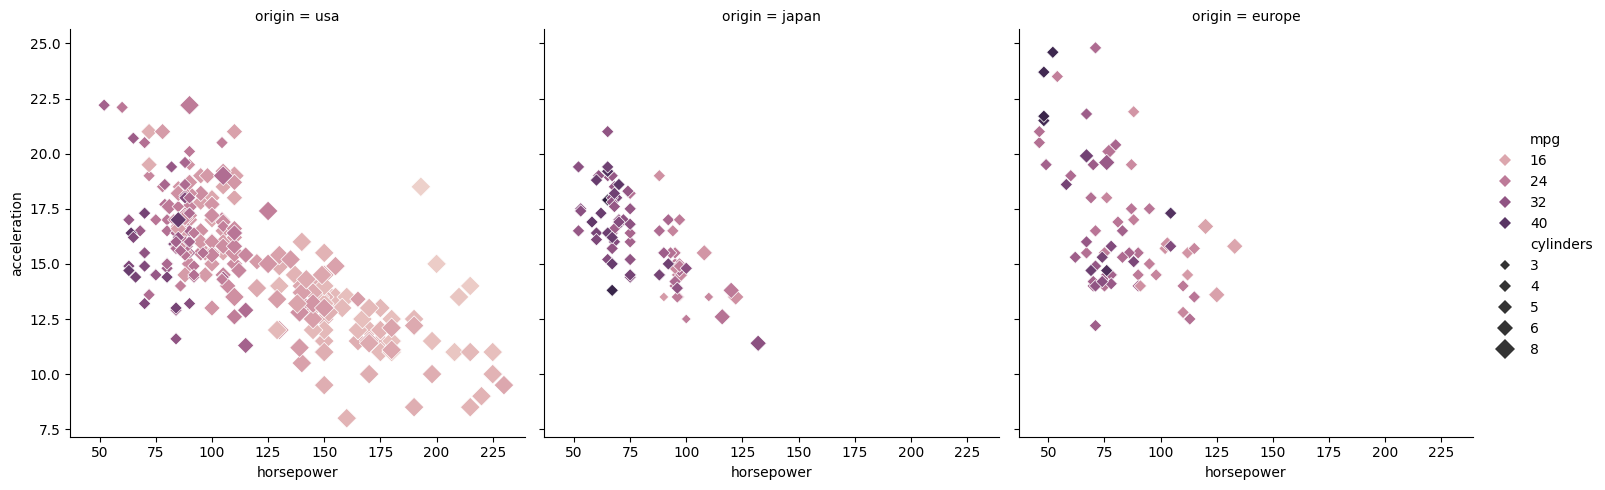

In [36]:
sns.relplot(x='horsepower', y='acceleration', hue='mpg',
            size='cylinders', col='origin', data=df, kind='scatter', sizes=(25, 100), alpha=1, marker='D')
plt.show()

Nhận xét:
1. Trong cả ba khu vực (Mỹ, Nhật Bản, và Châu Âu), có xu hướng chung là khi mã lực tăng, gia tốc giảm. Điều này có thể phản ánh rằng các xe mạnh hơn (mã lực lớn hơn) thường có trọng lượng nặng hơn, dẫn đến thời gian tăng tốc lâu hơn.
Tuy nhiên, mối tương quan này rõ ràng hơn đối với xe Mỹ so với Nhật Bản và Châu Âu.

2. Sự khác biệt theo nguồn gốc (origin):
- Mỹ: Xe có mã lực lớn hơn (trải dài từ 50 đến hơn 200 mã lực) nhưng sự phân bố gia tốc lại tập trung ở mức thấp hơn (10-20). Điều này cho thấy xe Mỹ thường có động cơ lớn nhưng khả năng tăng tốc không quá nhanh.
- Nhật Bản: Xe Nhật Bản tập trung ở dải mã lực thấp hơn (50-100 mã lực) và gia tốc ở mức cao hơn (12-20). Điều này có thể phản ánh rằng xe Nhật Bản thường ưu tiên thiết kế nhỏ gọn và khả năng tiết kiệm nhiên liệu hơn là sức mạnh động cơ.
- Châu Âu: Phân bố mã lực và gia tốc của xe Châu Âu khá đa dạng, với sự cân bằng giữa hiệu suất và khả năng tăng tốc. Xe Châu Âu có xu hướng nằm ở giữa Nhật Bản và Mỹ.

3. Mối quan hệ với số xi-lanh (cylinders):
- Xe có số xi-lanh lớn hơn (6 hoặc 8) thường tập trung ở Mỹ, đi kèm mã lực lớn và gia tốc thấp.
- Nhật Bản và Châu Âu chủ yếu sử dụng động cơ có 3 hoặc 4 xi-lanh, với mã lực thấp hơn và gia tốc cao hơn, phù hợp với thiết kế xe nhỏ và tiết kiệm nhiên liệu.

4. Mối quan hệ với mức tiêu thụ nhiên liệu (mpg):
- Các điểm dữ liệu với màu sắc đậm hơn (thể hiện mức tiêu thụ nhiên liệu cao hơn) chủ yếu xuất hiện ở Nhật Bản và Châu Âu. Trong khi đó, xe Mỹ với mã lực lớn hơn thường có màu nhạt (tiêu thụ nhiên liệu thấp hơn, tức mức mpg thấp hơn).
- Điều này cho thấy xe Nhật Bản và Châu Âu thường có hiệu suất nhiên liệu tốt hơn so với xe Mỹ.
5. Kết luận:
Biểu đồ cho thấy sự khác biệt rõ ràng trong thiết kế và hiệu suất xe giữa ba khu vực. Xe Mỹ tập trung vào sức mạnh và kích thước lớn, trong khi xe Nhật Bản và Châu Âu ưu tiên tính tiết kiệm và khả năng tăng tốc nhanh hơn.

##Các đặc trưng như hiệu suất nhiên liệu (mpg), mã lực (horsepower), dung tích xi-lanh (displacement), và trọng lượng xe (weight) thay đổi như thế nào theo năm sản xuất (model_year) ở từng khu vực (origin)?

variation of numerical features with model_year bifurcated by origin


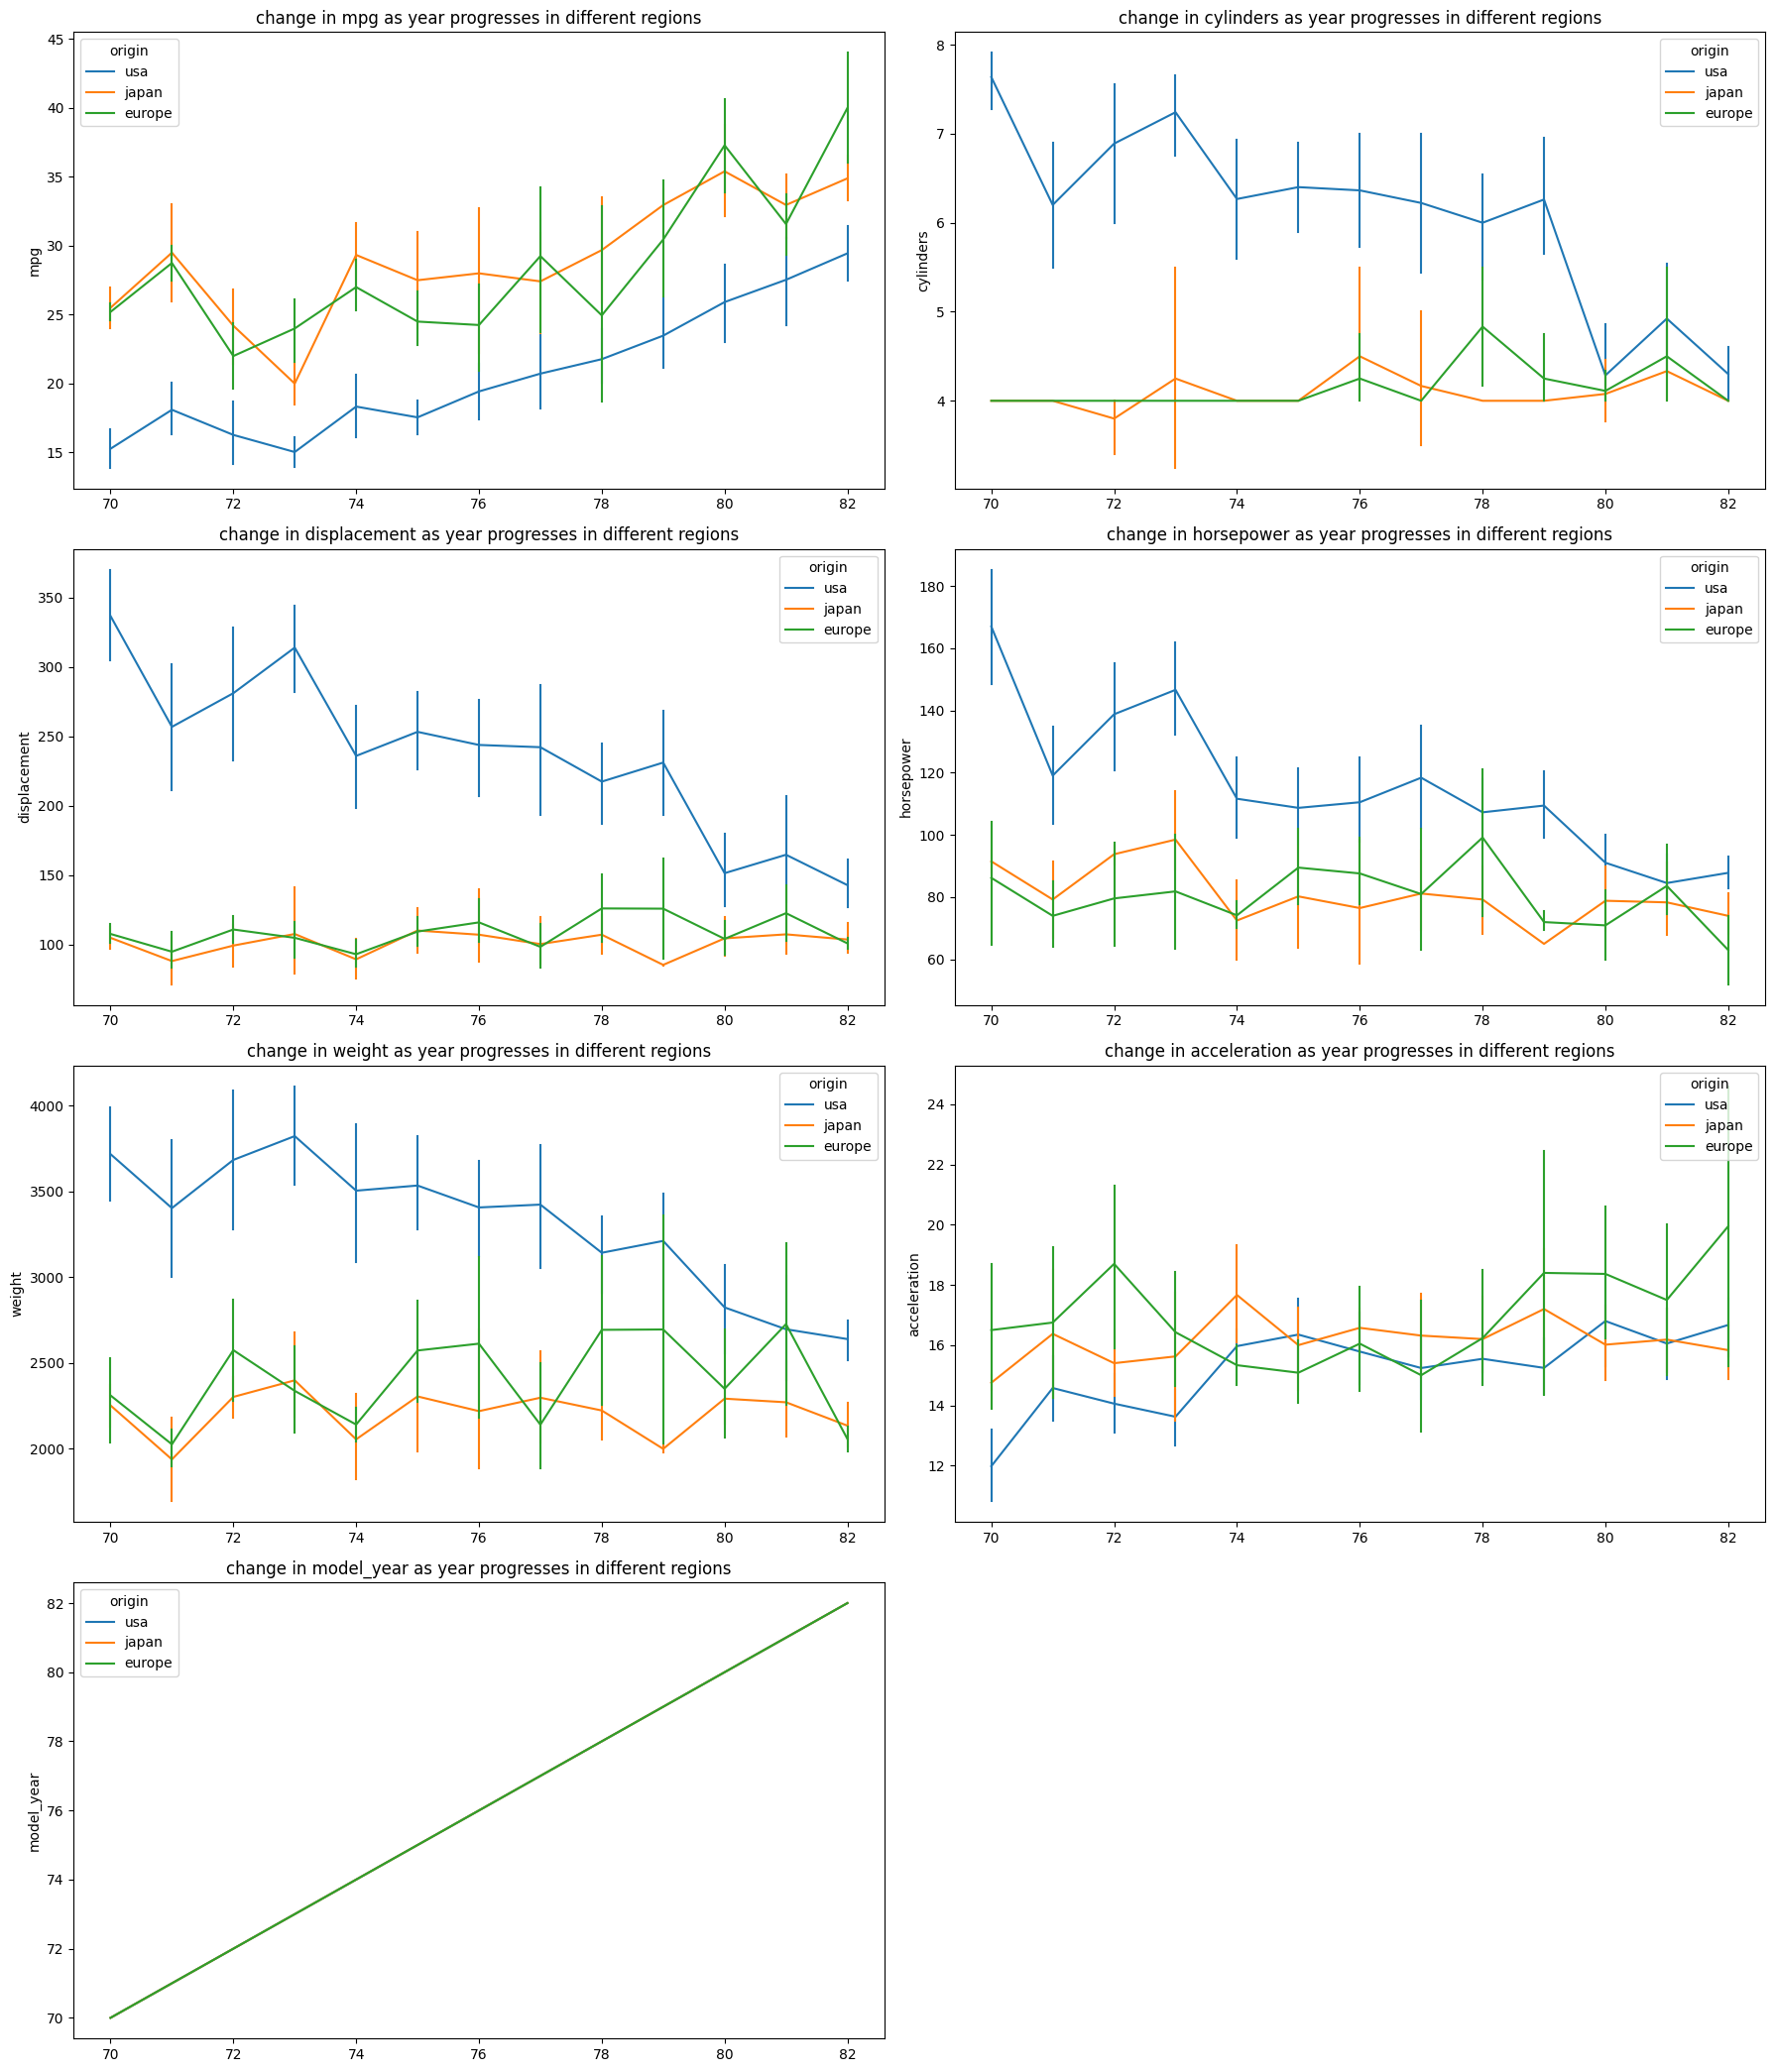

In [37]:
print('variation of numerical features with model_year bifurcated by origin')
fig = plt.figure(1, (18, 21))
num_features = len(nums)
num_cols = 2
num_rows = (num_features + num_cols - 1) // num_cols

for idx, col in enumerate(nums):
    ax = plt.subplot(num_rows, num_cols, idx + 1)
    sns.lineplot(x="model_year", y=col, hue='origin', data=df, err_style='bars')
    ax.set_title(f'change in {col} as year progresses in different regions')
    ax.set_xlabel(None)
    plt.tight_layout()

plt.show()

Nhận xét:
1. Theo thời gian, giá trị mpg (mức tiết kiệm nhiên liệu) có xu hướng tăng ở cả ba khu vực (USA, Japan, Europe).
- Nhật Bản có mức tăng mạnh nhất, thể hiện khả năng cải thiện tiết kiệm nhiên liệu đáng kể.
- Mỹ tăng chậm hơn, nhưng vẫn có cải thiện rõ rệt từ giữa thập niên 70.
- Châu Âu cũng có xu hướng tăng, nhưng không mạnh mẽ như Nhật Bản.
2. Horsepower giảm dần theo thời gian, đặc biệt rõ rệt ở Mỹ.
- Ở Mỹ, mã lực giảm đáng kể, có thể do các quy định về tiết kiệm nhiên liệu và môi trường được áp dụng trong thập niên 70.
- Nhật Bản và châu Âu giữ mức ổn định hơn, không có sự thay đổi lớn.
3. Trọng lượng xe giảm dần theo thời gian ở Mỹ, nhưng ít thay đổi ở Nhật Bản và châu Âu.
- Ở Mỹ, trọng lượng xe giảm từ những năm 70, có thể liên quan đến nỗ lực cải thiện hiệu suất nhiên liệu.
- Nhật Bản và châu Âu duy trì trọng lượng xe nhẹ hơn ngay từ đầu.
4. Displacement giảm dần theo thời gian, đặc biệt rõ rệt ở Mỹ.
- Xe Mỹ ban đầu có dung tích động cơ lớn hơn, nhưng đã giảm xuống đáng kể qua thời gian.
- Nhật Bản và châu Âu có dung tích động cơ nhỏ hơn và duy trì ổn định hơn.
5. Acceleration không có sự thay đổi rõ rệt qua các năm.
Khả năng tăng tốc ở cả ba khu vực khá đồng đều, không có sự cải thiện lớn nào qua thời gian.
